# Advanced Topics in Algorithms: Flow!

In [31]:
# We begin by importing all relevant functions!
import main as flow
import cv2
import pandas as pd
import matplotlib.pyplot as plt

## Establishing the problem!

First, we load in the relevant grid.

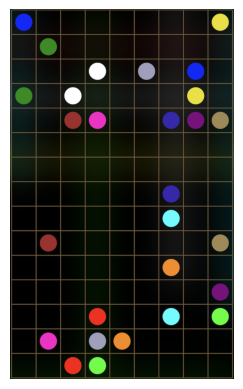

In [32]:
img = flow.load_img("examples/example_4.png")
plt.imshow(img)
plt.axis('off')
plt.show()

We now extract the locations of colors present, knowing the image is a 9x9 grid. Note that the length of our information will be 28, as there are 14 colors (each as a pair) on the grid!

In [33]:
num_rows = 15
num_cols = 9
information = flow.fetch_information(img, num_rows, num_cols)

Let's print out the information that we have fetched, and confirm that it looks right!

In [34]:
rows = []
for info in information:
    color, [r, c], label = info
    rows.append([r, c, color[0], color[1], color[2], label])

df = pd.DataFrame(rows, columns=["Row", "Col", "R", "G", "B", "Source/sink"])

print("="*20, "information fetched", "="*20)
print(df.sort_values(by=["R", "Source/sink"]).reset_index(drop=True))

print("="*20, "information fetched", "="*20)
# Confirming the number of colors:
num_colors = len(information)//2
print("There are", num_colors, "unique colors on the grid :)")

==================== information fetched ====================
    Row  Col      R      G      B Source/sink
0     0    0   20.0   40.0  243.0           s
1     2    7   20.0   40.0  243.0           t
2     4    6   53.0   41.0  170.0           s
3     7    6   53.0   41.0  170.0           t
4     1    1   61.0  138.0   38.0           s
5     3    0   61.0  138.0   38.0           t
6     4    7  116.0   20.0  123.0           s
7    11    8  116.0   20.0  123.0           t
8     8    6  117.0  251.0  253.0           s
9    12    8  117.0  251.0   76.0           s
10   12    6  117.0  251.0  253.0           t
11   14    3  117.0  251.0   76.0           t
12    4    2  151.0   52.0   47.0           s
13    9    1  151.0   52.0   47.0           t
14    4    8  156.0  138.0   89.0           s
15    9    8  156.0  138.0   89.0           t
16    2    5  159.0  159.0  187.0           s
17   13    3  159.0  159.0  187.0           t
18    0    8  232.0  223.0   73.0           s
19    3    7  232.

To use the colors more efficiently in the linear program, we map them to integer values. For this grid, the colors will map to indices 0-13.

In [35]:
color_dictionary, _ = flow.create_color_dictionary(information)

Now, let print out the color dictionary to make it concrete!

In [36]:
for key, value in color_dictionary.items():
    print(f"{key}: {value}")

(np.float64(20.0), np.float64(40.0), np.float64(243.0)): 0
(np.float64(232.0), np.float64(223.0), np.float64(73.0)): 1
(np.float64(61.0), np.float64(138.0), np.float64(38.0)): 2
(np.float64(255.0), np.float64(255.0), np.float64(255.0)): 3
(np.float64(159.0), np.float64(159.0), np.float64(187.0)): 4
(np.float64(151.0), np.float64(52.0), np.float64(47.0)): 5
(np.float64(234.0), np.float64(53.0), np.float64(194.0)): 6
(np.float64(53.0), np.float64(41.0), np.float64(170.0)): 7
(np.float64(116.0), np.float64(20.0), np.float64(123.0)): 8
(np.float64(156.0), np.float64(138.0), np.float64(89.0)): 9
(np.float64(117.0), np.float64(251.0), np.float64(253.0)): 10
(np.float64(236.0), np.float64(142.0), np.float64(52.0)): 11
(np.float64(234.0), np.float64(51.0), np.float64(35.0)): 12
(np.float64(117.0), np.float64(251.0), np.float64(76.0)): 13


We are now ready for *LP*!!

## Modeling Flow as a Linear Program!

We will use two methods to model Flow as a linear program: Connectivity and Multi-Commodity Flow :)

### *Formulation 1*: Connectivity!
We try to solve the problem via connectivity. For this formulation, we index over three sets: $\texttt{ROWS}$, $\texttt{COLUMNS}$, and $\texttt{COLORS}$. As with any linear program, we now need to define the **Decision Variables**, **Objective Function**, and **Constraints**.

#### Decision Variables
Let $x_{i,j,k}$ be the binary variable whose value is specified in the following way:
$$
x_{i,j,k} = \begin{cases}
        1 & \text{if the tile at coordinate $(i,j)$ takes on color $k$}\\
        0 & \text{otherwise}
    \end{cases}
$$

#### Objective Function

Do we need an objective for the problem? **No.** 

We care about the feasibility of the problem, meaning that all we need is a feasible coloring so that all flows are connected and do not intersect. Therefore, the objective function could simply be $\{\max \ 0\}$.


#### Constraints
Each tile must be colored with precisely one color, so we have
$$
    \sum_{k \in \texttt{COLORS}} x_{i,j,k} = 1\hspace{.5in}\text{for all $i\in \texttt{ROWS}$ and $j \in \texttt{COLUMNS}$.}
$$


**How should we enforce connectivity?** By observing a flow solution (likke the one in Figure 2 on the handout :0) we observe that:

- If tile $(i,j)$ is an $\texttt{END-TILE}$ of color $k$, we need precisely one of its 4-neighbors to take on color $k$. This can be represented by the following pair of coupled constraints.$$\begin{align*}
            x_{i-1,j,k} + x_{i+1,j,k} + x_{i,j-1,k}+x_{i,j+1,k} &\geq x_{i,j,k}\\
            x_{i-1,j,k} + x_{i+1,j,k} + x_{i,j-1,k}+x_{i,j+1,k} &\leq 4-3\cdot x_{i,j,k}
        \end{align*}$$
        The smart thing about this formulation is that
  - When $x_{i,j,k} = 0$ (the $(i,j)$ tile is not an $\texttt{END-TILE}$ for color $k$), the constraints do not force anything.
  - When $x_{i,j,k} = 1$ (the $(i,j)$ tile is an $\texttt{END-TILE}$ for color $k$), the constraints force that precisely one of the 4-neighbors should also take on color $k$.
- If tile $(i,j)$ is colored in color $k$ but is not one of the $\texttt{END-TILE}\text{s}$ (a $\texttt{MIDDLE-TILE}$) of color $k$, we need precisely two of its 4-neighbors to take on color $k$. In a similar fashion, we introduce the following pair of coupled constraints.$$\begin{align*}
            x_{i-1,j,k} + x_{i+1,j,k} + x_{i,j-1,k}+x_{i,j+1,k} &\geq 2\cdot x_{i,j,k}\\
            x_{i-1,j,k} + x_{i+1,j,k} + x_{i,j-1,k}+x_{i,j+1,k} &\leq 4-2\cdot x_{i,j,k}
        \end{align*}$$


In [37]:
x = flow.connectivity_solver(num_rows, num_cols, num_colors, information, color_dictionary)

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/mingbeiliu/.pyenv/versions/3.11.15/lib/python3.11/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/m0/fzb966955yl09v443vdt8lq40000gn/T/019f134e545444a392a388de5cc45282-pulp.mps -max -timeMode elapsed -branch -printingOptions all -solution /var/folders/m0/fzb966955yl09v443vdt8lq40000gn/T/019f134e545444a392a388de5cc45282-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 4733 COLUMNS
At line 33463 RHS
At line 38192 BOUNDS
At line 40812 ENDATA
Problem MODEL has 4728 rows, 2619 columns and 23492 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.01 seconds
Cgl0002I 728 variables fixed
Cgl0003I 627 fixed, 0 tightened bounds, 412 strengthened rows, 192 substitutions
Cgl0003I 304 fixed, 0 tightened bounds, 24 strengthened rows, 113 substitutions
Cgl0003I 107 fixed, 0 tighte

Now having solved the problem, let's visualize the output! To do so, we first see which color was determined to be on each tile.

In [38]:
for (i, j, k), var in x.items():
    if var.value() == 1:
        print(f"({i}, {j}) -> color {k}")

(0, 0) -> color 0
(0, 1) -> color 0
(0, 2) -> color 0
(0, 3) -> color 0
(0, 4) -> color 0
(0, 5) -> color 0
(0, 6) -> color 0
(0, 7) -> color 0
(0, 8) -> color 1
(1, 0) -> color 2
(1, 1) -> color 2
(1, 2) -> color 12
(1, 3) -> color 12
(1, 4) -> color 12
(1, 5) -> color 12
(1, 6) -> color 12
(1, 7) -> color 0
(1, 8) -> color 1
(2, 0) -> color 2
(2, 1) -> color 12
(2, 2) -> color 12
(2, 3) -> color 3
(2, 4) -> color 4
(2, 5) -> color 4
(2, 6) -> color 12
(2, 7) -> color 0
(2, 8) -> color 1
(3, 0) -> color 2
(3, 1) -> color 12
(3, 2) -> color 3
(3, 3) -> color 3
(3, 4) -> color 4
(3, 5) -> color 12
(3, 6) -> color 12
(3, 7) -> color 1
(3, 8) -> color 1
(4, 0) -> color 12
(4, 1) -> color 12
(4, 2) -> color 5
(4, 3) -> color 6
(4, 4) -> color 4
(4, 5) -> color 12
(4, 6) -> color 7
(4, 7) -> color 8
(4, 8) -> color 9
(5, 0) -> color 12
(5, 1) -> color 5
(5, 2) -> color 5
(5, 3) -> color 6
(5, 4) -> color 4
(5, 5) -> color 12
(5, 6) -> color 7
(5, 7) -> color 8
(5, 8) -> color 9
(6, 0) -> co

Oops, that is not so intuitive... let's adopt a better visualization!

In [39]:
solution_grid_x = flow.get_solution_x(x, num_rows, num_cols, num_colors)

# for color in range(num_colors):
#     print(solution_grid_x[color])

color = 0
print(solution_grid_x[color])

[[1 1 1 1 1 1 1 1 0]
 [0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]]


That's a little better, but wouldn't it be great if we could have the solutions automatically be filled on the original image?

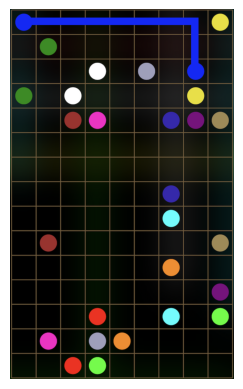

In [40]:
# for color in range(num_colors):
#     img_copy = img.copy()
#     visualization = flow.create_visualization(img_copy, solution_grid_x, color_dictionary, color, information, num_rows, num_cols)
#     plt.imshow(cv2.cvtColor(visualization, cv2.COLOR_BGR2RGB))
#     plt.axis('off')
#     plt.show()

img_copy = img.copy()
visualization = flow.create_visualization(img_copy, solution_grid_x, color_dictionary, color, information, num_rows, num_cols)
plt.imshow(cv2.cvtColor(visualization, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


Great! Now we just need to stitch all flows together as our final answer!

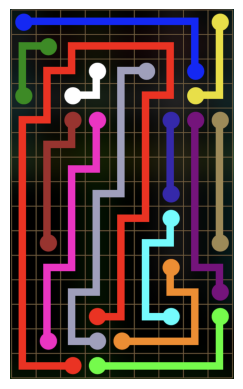

In [41]:
visualization = img.copy()
visualization = flow.create_visualization_for_all_colors(visualization, solution_grid_x, color_dictionary, num_colors, information, num_rows, num_cols, half_width=10)
plt.imshow(cv2.cvtColor(visualization, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

Yay!! Now let's move onto the second LP formulation :)

<!-- ![Alt Text](little_guy.png) -->
<img src="little_guy.png" width="25%">

### *Formulation 2*: Multi-Commodity Flow

For the second formulation, we first need to make our grid into a graph!

#### From Grid to Graph

We first determine the the vertex set $V$ and edge set $E$.

In [42]:
V, E = flow.create_V_and_E(num_rows, num_cols)

<!-- ***NOTE:** The use of flow in the following box is different from our definition from above. We will be talking about flow as in network flow, not flow as in a path in the hit mobile game Flow!* -->

We will represent each flow as a directed path from an arbitrarily chosen starting colored dot (refered to as its $\texttt{SOURCE}$) to the other colored dot of the same color (referred to as its $\texttt{SINK}$).

To allow flow to travel through the graph, we represent each tile on the grid with two vertices where:

* one sends outgoing edges to its neighbors
* one takes in all incoming edges from its neighbors

Let the first node be the "out" node and the second be the "in" node corresponding to the tile. We then add an edge from the "in" node to the "out" node. This formulation ensures that only one flow passes through each tile!

In [43]:
print("="*20, "Vertices (part)", "="*20)
for i in range(0, min(len(V), 5), 5):
    chunk = list(V)[i:i+5]
    print("   ".join(f"({a},{b},{c})" for a, b, c in chunk))

print("="*20, "Edges (part)", "="*20)
for i in range(0, min(len(E), 6), 2):
    chunk = list(E)[i:i+2]
    print("   ".join(f"{u}-{v}" for u, v in chunk))

==================== Vertices (part) ====================
(0,0,in)   (0,0,out)   (0,1,in)   (0,1,out)   (0,2,in)
==================== Edges (part) ====================
(0, 0, 'out')-(1, 0, 'in')   (0, 0, 'out')-(0, 1, 'in')
(0, 0, 'in')-(0, 0, 'out')   (0, 1, 'out')-(1, 1, 'in')
(0, 1, 'out')-(0, 0, 'in')   (0, 1, 'out')-(0, 2, 'in')


**Decision Variables**

Let $f_{u,v,k}$ denote the number of units of flow $k$ that we push along the edge $(u,v)$. We are not interested in the amount of flow we are able to push. Rather, we are interested in finding a $\textit{feasible}$ solution that sends flow $k$ from its source to its sink. Furthermore, to avoid fractions in the final solution, we enforce that $f_{u,v,k}$ is binary.

**Objective Function**

Much like the connectivity formulation, this is also a feasibility problem. Thus, the objective is once again $\{\max\ 0\}$.

**Constraints**

We first introduce the $\textit{capacity constraint}$ that at most one unit of flow, regardless of its color, can be pushed along each edge. That is,
$$
    \sum_{k \in \texttt{COLORS}} f_{u,v,k} \leq 1\hspace{.5in} \text{for all $(u,v) \in \texttt{EDGES}$.}
$$

Next, we introduce $\textit{flow balance constraints}$. For each vertex $v$, the incoming and outgoing flows are given as follows
$$\begin{align*}
    \text{Inflow}(v) = \sum_{\substack{k \in \texttt{COLORS},\\
    \text{$u$ where $(u,v) \in \texttt{EDGES}$}}} f_{u,v,k}, \hspace{0.65in} \text{Outflow}(v) = \sum_{\substack{k \in \texttt{COLORS},\\
    \text{$u$ where $(v,u) \in \texttt{EDGES}$}}} f_{v,u,k}.
\end{align*}$$



- For $\texttt{SOURCE}$ vertices, we demand $\text{Outflow}(v) - \text{Inflow}(v) = 1$.
- For $\texttt{SINK}$ vertices, we demand $\text{Inflow}(v) - \text{Outflow}(v) = 1$.
- For all $\texttt{TRANSSHIPMENT}$ (intermediate) vertices, we demand $\text{Inflow}(v) - \text{Outflow}(v) = 0$.


In [44]:
f = flow.multi_commodity_flow_solver(num_rows, num_cols, num_colors, information, color_dictionary)

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/mingbeiliu/.pyenv/versions/3.11.15/lib/python3.11/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/m0/fzb966955yl09v443vdt8lq40000gn/T/f674cb53c884442fbe8bf7d230a4da9d-pulp.mps -max -timeMode elapsed -branch -printingOptions all -solution /var/folders/m0/fzb966955yl09v443vdt8lq40000gn/T/f674cb53c884442fbe8bf7d230a4da9d-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 4412 COLUMNS
At line 48304 RHS
At line 52712 BOUNDS
At line 61492 ENDATA
Problem MODEL has 4407 rows, 8779 columns and 26334 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.06 seconds
Cgl0003I 1 fixed, 0 tightened bounds, 190 strengthened rows, 0 substitutions
Cgl0003I 0 fixed, 0 tightened bounds, 91 strengthened rows, 0 substitutions
Cgl0003I 0 fixed, 0 tightened bounds, 183 strengthened rows, 0 su

Having solved the LP, we can use similar methods as for connectivity to determine how to color our grid!

In [45]:
for (u, v, k), var in f.items():
    if var.value() == 1:
        print(f"Color k = {k} from u = {u}, v = {v}")

Color k = 0 from u = (0, 0, 'out'), v = (0, 1, 'in')
Color k = 0 from u = (0, 0, 'in'), v = (0, 0, 'out')
Color k = 0 from u = (0, 1, 'out'), v = (0, 2, 'in')
Color k = 0 from u = (0, 1, 'in'), v = (0, 1, 'out')
Color k = 0 from u = (0, 2, 'out'), v = (0, 3, 'in')
Color k = 0 from u = (0, 2, 'in'), v = (0, 2, 'out')
Color k = 0 from u = (0, 3, 'out'), v = (0, 4, 'in')
Color k = 0 from u = (0, 3, 'in'), v = (0, 3, 'out')
Color k = 0 from u = (0, 4, 'out'), v = (0, 5, 'in')
Color k = 0 from u = (0, 4, 'in'), v = (0, 4, 'out')
Color k = 0 from u = (0, 5, 'out'), v = (0, 6, 'in')
Color k = 0 from u = (0, 5, 'in'), v = (0, 5, 'out')
Color k = 0 from u = (0, 6, 'out'), v = (0, 7, 'in')
Color k = 0 from u = (0, 6, 'in'), v = (0, 6, 'out')
Color k = 0 from u = (0, 7, 'out'), v = (1, 7, 'in')
Color k = 0 from u = (0, 7, 'in'), v = (0, 7, 'out')
Color k = 0 from u = (1, 7, 'out'), v = (2, 7, 'in')
Color k = 0 from u = (1, 7, 'in'), v = (1, 7, 'out')
Color k = 0 from u = (2, 7, 'in'), v = (2, 7, 

We once again formulate the path as an array of zeros and ones...

In [46]:
solution_grid_f = flow.get_solution_f(f, num_rows, num_cols, num_colors)
# for color in range(num_colors):
#     print(solution_grid_f[color])

print(solution_grid_f[color])

[[1 1 1 1 1 1 1 1 0]
 [0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]]


...and finally as a visualization on the grid!

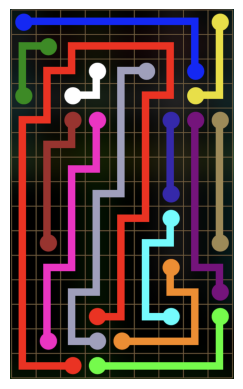

In [47]:
visualization_f = img.copy()
visualization_f = flow.create_visualization_for_all_colors(visualization_f, solution_grid_x, color_dictionary, num_colors, information, num_rows, num_cols, half_width=10)
plt.imshow(cv2.cvtColor(visualization_f, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

And we have now solved the flow instance two different ways :)

<img src="little_guy.png" width="25%">